In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)
X

array([[-8.28739184,  8.7909197 ],
       [ 0.4395115 , -3.49565199],
       [-0.77240526, -4.39320623],
       ...,
       [ 0.81863903, -6.09070625],
       [-7.70185771,  8.83722869],
       [ 3.8046989 , -6.41092716]], shape=(1000, 2))

In [3]:
y

array([1, 2, 2, 1, 2, 0, 2, 2, 0, 1, 0, 1, 0, 1, 2, 1, 1, 0, 1, 2, 2, 2,
       0, 0, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 0, 0,
       0, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1, 2, 0, 0, 2, 2, 0, 2, 2, 1, 1,
       1, 1, 2, 1, 2, 1, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 1, 1, 1, 2, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 2, 2, 1, 2, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 0, 2, 0, 1,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 2,
       0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 0, 2, 2, 1, 1, 0, 2, 0, 2, 1, 1, 2, 0, 0, 2, 0, 0, 2, 1,
       0, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 0, 1, 2, 1, 2, 1, 0, 2,
       2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 1, 1, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 2, 0, 1, 2, 2, 0, 1, 0, 0, 0, 1, 0, 2, 1, 0, 0, 2, 2,
       1, 1, 2, 2, 1, 0, 0, 0, 2, 0, 2, 1, 2, 1, 0, 2, 2, 2, 1, 2, 0, 2,
       1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1,

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.35,random_state=10)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [5]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,12):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train,y_train)
    wcss.append(kmeans.inertia_)
wcss

[1299.9999999999984,
 107.21721855011498,
 37.19290108086092,
 31.154499773051427,
 26.412934901521446,
 24.1012168255545,
 20.666211920043203,
 17.940987030117242,
 16.803330217682706,
 15.23849797539705,
 13.368062759003918]

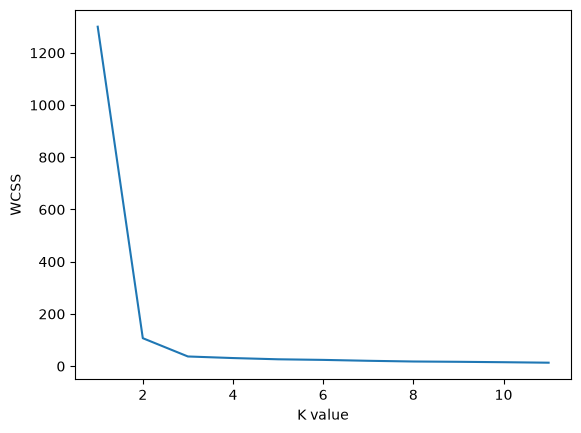

In [6]:
plt.plot(range(1,12),wcss)
plt.xlabel('K value')
plt.ylabel('WCSS')
plt.show()

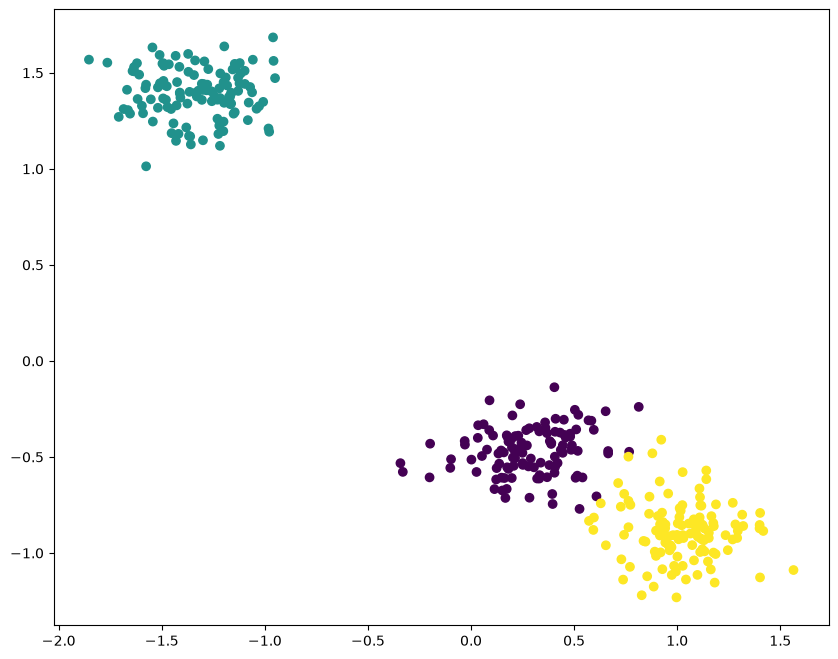

In [7]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit(X_train,y_train)
y_pred=kmeans.predict(X_test)
plt.figure(figsize=(10,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

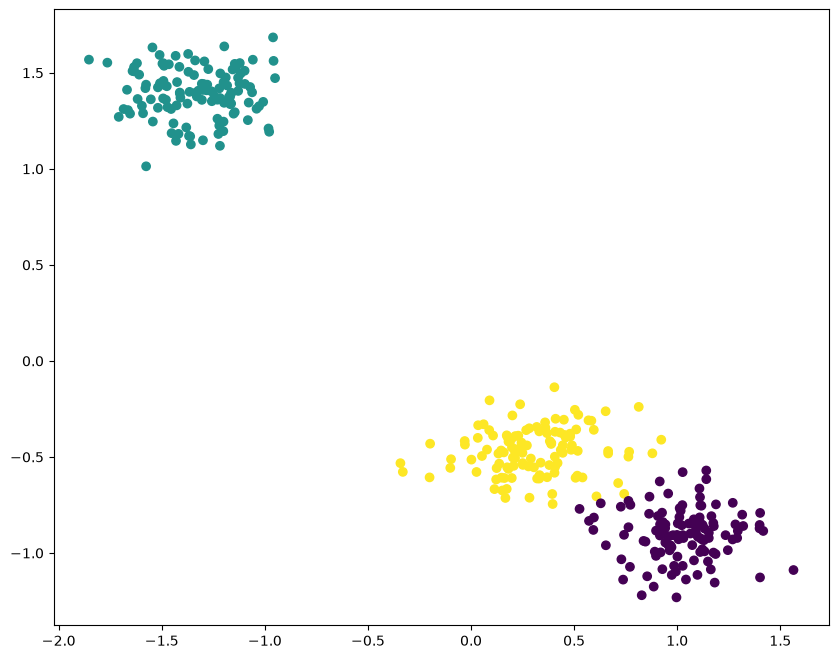

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.show()

In [9]:
!pip install Kneed

In [10]:
from kneed import KneeLocator
kl=KneeLocator(range(1,12),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(2)

In [13]:
from sklearn.metrics import silhouette_score
silhouette_coeff=[]
for k in range(2,12):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train,y_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coeff.append(score)
silhouette_coeff

[0.8317873312806477,
 0.7047465528292123,
 0.5912162174350211,
 0.5314694842160441,
 0.3530610057290484,
 0.3545781977286313,
 0.3367294375241789,
 0.34111604573348164,
 0.3439545005527633,
 0.34037737380367344]

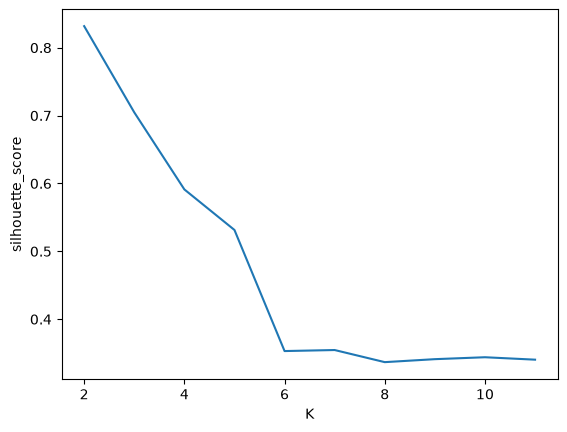

In [17]:
plt.plot(range(2,12),silhouette_coeff)
plt.xlabel('K')
plt.ylabel('silhouette_score')
plt.show()

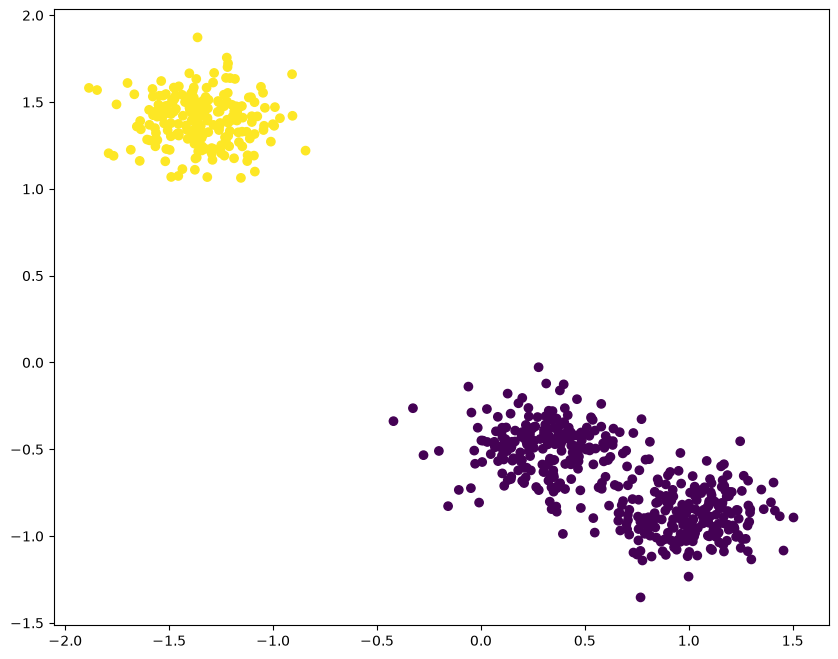

In [19]:
kmeans=KMeans(n_clusters=2,init='k-means++')
kmeans.fit(X_train,y_train)
y_pred=kmeans.predict(X_train)
plt.figure(figsize=(10,8))
plt.scatter(X_train[:,0],X_train[:,1],c=y_pred)
plt.show()